In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from google.colab import drive

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
%matplotlib inline

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
from PIL import Image  


base_path = '/content/drive/MyDrive/Face_Dataset/' 


class_names = sorted(os.listdir(base_path))  
num_classes = len(class_names)
print("Group mates:", class_names)

# Load images
x_data = []
y_data = []

target_size = (64, 64) 

for idx, name in enumerate(class_names):
    folder_path = os.path.join(base_path, name)
    print(f"Loading images from: {name}")
    for img_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_name)
        try:
            img = Image.open(img_path).convert('L')  # Convert to grayscale
            img = img.resize(target_size)
            img_array = np.array(img) / 255.0  # Normalize
            x_data.append(img_array)
            y_data.append(idx)
        except:
            print(f"Skipped bad image: {img_path}")

x_data = np.array(x_data)
y_data = np.array(y_data)

# Add channel dimension: (samples, 64, 64, 1)
x_data = x_data.reshape(-1, 64, 64, 1)

print(f"Total images loaded: {len(x_data)}")
print(f"Shape of x_data: {x_data.shape}")
print(f"Shape of y_data: {y_data.shape}")

Group mates: ['Abir', 'DIPANKAR', 'Mehedi']
Loading images from: Abir
Skipped bad image: /content/drive/MyDrive/Face_Dataset/Abir/IMG_6340.HEIC
Skipped bad image: /content/drive/MyDrive/Face_Dataset/Abir/IMG_6342.HEIC
Skipped bad image: /content/drive/MyDrive/Face_Dataset/Abir/IMG_6336.HEIC
Skipped bad image: /content/drive/MyDrive/Face_Dataset/Abir/IMG_6341.HEIC
Skipped bad image: /content/drive/MyDrive/Face_Dataset/Abir/IMG_6345.HEIC
Loading images from: DIPANKAR
Loading images from: Mehedi
Total images loaded: 36
Shape of x_data: (36, 64, 64, 1)
Shape of y_data: (36,)


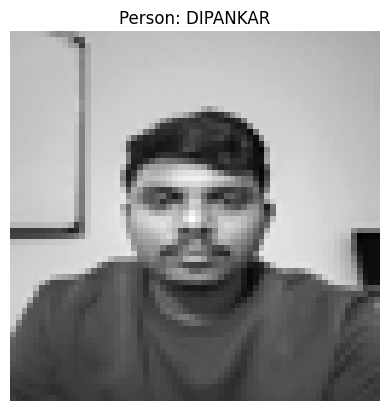

In [ ]:
person_idx = 15  
plt.imshow(x_data[person_idx].reshape(64, 64), cmap='gray')
plt.title(f"Person: {class_names[y_data[person_idx]]}")
plt.axis('off')
plt.show()

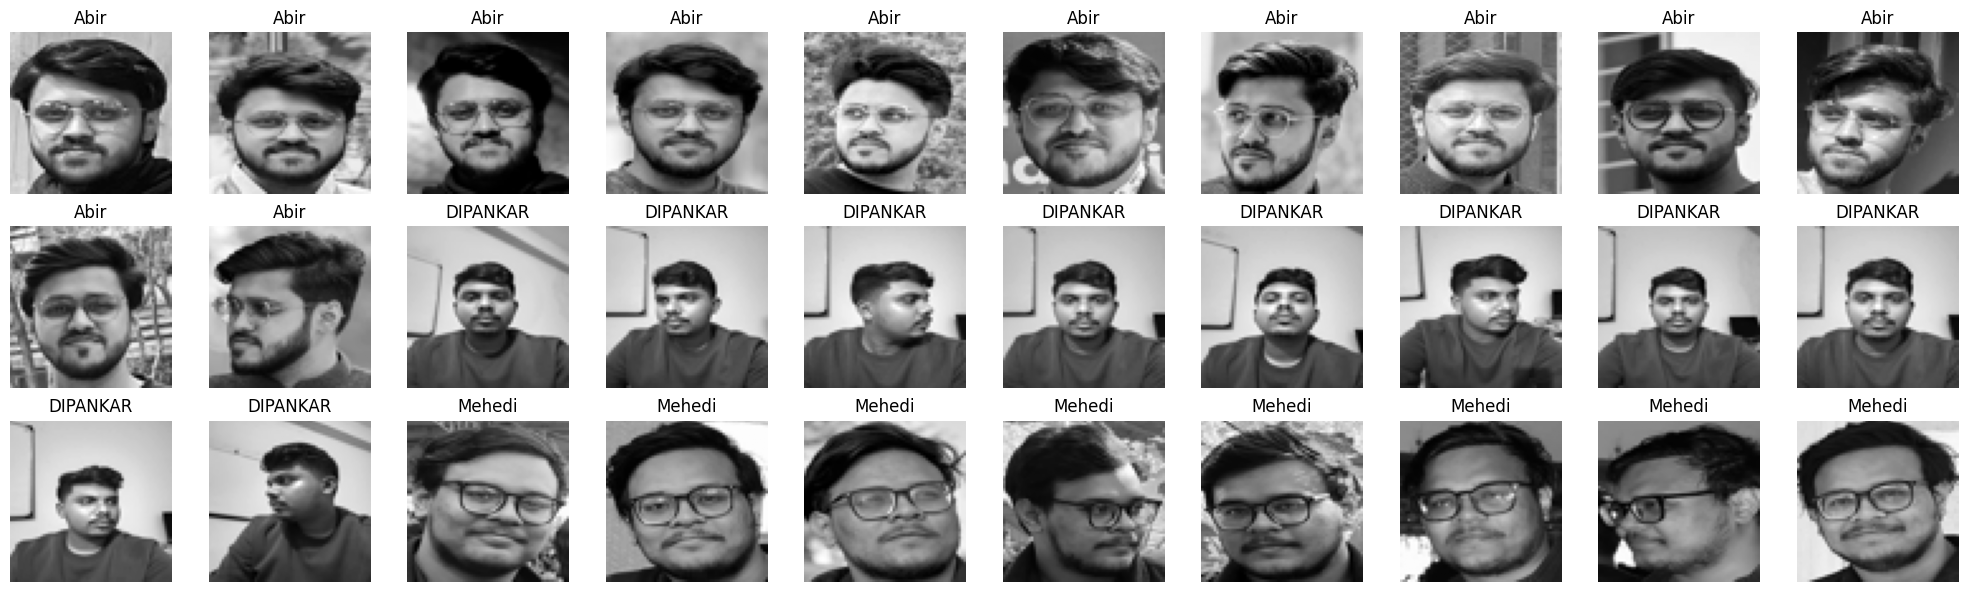

In [5]:
plt.figure(figsize=(20, 6))
for i in range(30):  # Show first 30 images
    if i >= len(x_data):
        break
    plt.subplot(3, 10, i + 1)
    plt.imshow(x_data[i].reshape(64, 64), cmap='gray')
    plt.title(class_names[y_data[i]])
    plt.axis('off')
plt.tight_layout()
plt.show()

In [6]:
# Split into train and test
x_train, x_test, y_train, y_test = train_test_split(
    x_data, y_data, test_size=0.2, random_state=42, stratify=y_data
)

print(f"Training samples: {len(x_train)}")
print(f"Testing samples: {len(x_test)}")

# Build a simple but effective CNN
model = keras.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(64,64,1)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.Flatten(),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Training samples: 28
Testing samples: 8


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       589,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 645,827 (2.46 MB)

 Trainable params: 645,827 (2.46 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
history = model.fit(
    x_train, y_train,
    epochs=20,  # You can reduce if overfitting
    validation_data=(x_test, y_test),
    batch_size=8
)

Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 205ms/step - accuracy: 0.2625 - loss: 1.2204 - val_accuracy: 0.5000 - val_loss: 1.0848
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.5327 - loss: 1.0798 - val_accuracy: 0.6250 - val_loss: 1.0646
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - accuracy: 0.5845 - loss: 1.0579 - val_accuracy: 0.6250 - val_loss: 1.0286
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 138ms/step - accuracy: 0.6881 - loss: 0.9730 - val_accuracy: 0.5000 - val_loss: 0.9201
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - accuracy: 0.6381 - loss: 0.8277 - val_accuracy: 0.7500 - val_loss: 0.7028
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.7381 - loss: 0.6033 - val_accuracy: 1.0000 - val_loss: 0.4329
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.7851 - loss: 0.3910 - val_accuracy: 1.0000 - val_loss: 0.2775
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.8696 - loss: 0.3911 - val_accuracy: 0.8750 - val_loss: 0.2

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 1.0000 - loss: 0.0529

Test Accuracy: 1.0000


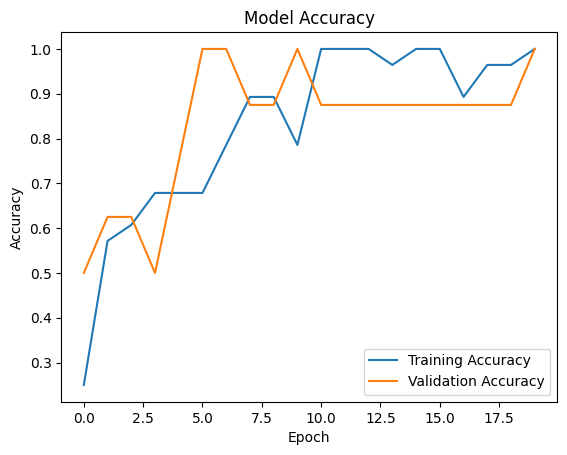

In [8]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"\nTest Accuracy: {test_acc:.4f}")

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [9]:
# Create folder if not exists
save_folder = '/content/drive/MyDrive/Face_Attendance_Model'
os.makedirs(save_folder, exist_ok=True)

model.save(os.path.join(save_folder, 'face_recognition_model.keras'))
print("Model saved successfully!")

Model saved successfully!
